# Lanzarote Weekly Audit + EDA

**Project:** Climate–Mortality  
#### EDA scope for this notebook
#### Island: set via `lanzarote`
#### Dataset version used here: 2016–2025

**Saved outputs:** QA tables and key descriptive tables (CSV) under `reports/islands/tables/lanzarote`.

## 0. Setup

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ISLAND_NAME = "lanzarote"
ISLAND_CODE = "lzt"

CWD = Path.cwd().resolve()

# If running from islands/<island>, go up two levels to repo root
if CWD.name == ISLAND_NAME and CWD.parent.name == "islands":
    ROOT = CWD.parent.parent
else:
    ROOT = CWD

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("CWD :", CWD)
print("ROOT:", ROOT)
print("src exists?:", (ROOT / "src").exists())

from src.utils.d25_nb_utils import (
    section, glance, checks, missing_table, num_summary,
    autosave_fig, save_table,
)

REPORTS_DIR = ROOT / "reports" / "islands"
FIG_DIR = REPORTS_DIR / "figures" / ISLAND_NAME
TAB_DIR = REPORTS_DIR / "tables" / ISLAND_NAME

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)

FP = ROOT / "data/processed" / ISLAND_NAME / "master" / f"master_{ISLAND_CODE}_2016_2025.parquet"
print("FP:", FP)
assert FP.exists(), f"Missing file: {FP}"

CWD : C:\Users\fdora\RA_Career\Projects\climate_mortality\islands\lanzarote
ROOT: C:\Users\fdora\RA_Career\Projects\climate_mortality
src exists?: True
FIG_DIR: C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\figures\lanzarote
TAB_DIR: C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\lanzarote
FP: C:\Users\fdora\RA_Career\Projects\climate_mortality\data\processed\lanzarote\master\master_lzt_2016_2025.parquet


## 1. Load data
Load the island master dataset and subset.

In [2]:
section(f"EDA core weekly {ISLAND_NAME}")

df = pd.read_parquet(FP)
print("Loaded:", FP)

df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
print("Week range:", df["week_start"].min(), "->", df["week_start"].max())
glance(df, label=f"eda_core_weekly_{ISLAND_CODE}", n=5)

checks(
    df,
    required=["week_start", "deaths_week"],
    key=["week_start"],
    dt="week_start"
)

num_summary(df)



EDA core weekly lanzarote
Loaded: C:\Users\fdora\RA_Career\Projects\climate_mortality\data\processed\lanzarote\master\master_lzt_2016_2025.parquet
Week range: 2015-12-28 00:00:00 -> 2025-12-29 00:00:00

--- eda_core_weekly_lzt ---
shape: (523, 42)

dtypes:
 week_start                     datetime64[ns]
year                                    int32
island                                 object
island_code                            object
deaths_week                           float64
deaths_missing_week                   float64
n_days                                  int64
temp_c_mean                           float64
tmax_c_mean                           float64
tmax_c_max                            float64
tmin_c_mean                           float64
tmin_c_min                            float64
humidity_mean                         float64
pressure_hpa_mean                     float64
wind_ms_mean                          float64
prec_sum                              float64
cover

,week_start,year,island,island_code,deaths_week,deaths_missing_week,n_days,temp_c_mean,tmax_c_mean,tmax_c_max,...,O3,days_with_pm10,days_missing_pm10,cap_heat_level_max_week,cap_dust_level_max_week,cap_heat_yellow_plus_week,cap_dust_yellow_plus_week,cap_coverage_week,calima_dai_flag,calima_level_week
0,2015-12-28,2015,lanzarote,lzt,NaN,NaN,3,18.366667,22.833333,23.7,...,63.000000,3,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,2016-01-04,2016,lanzarote,lzt,15.0,0.0,7,18.585714,22.671429,23.9,...,72.714286,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,2016-01-11,2016,lanzarote,lzt,15.0,0.0,7,19.028571,23.928571,26.8,...,70.000000,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3,2016-01-18,2016,lanzarote,lzt,14.0,0.0,7,19.300000,23.528571,25.1,...,70.000000,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4,2016-01-25,2016,lanzarote,lzt,11.0,0.0,7,18.785714,22.928571,24.3,...,82.857143,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0


,count,mean,std,min,25%,50%,75%,max
year,523.0,2020.491396,2.883003,2015.000000,2018.000000,2020.000000,2023.000000,2025.000000
deaths_week,522.0,15.927203,4.690668,4.000000,13.000000,15.000000,19.000000,31.000000
deaths_missing_week,522.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
n_days,523.0,6.950287,0.311674,3.000000,7.000000,7.000000,7.000000,7.000000
temp_c_mean,523.0,21.836416,3.057060,14.500000,19.114286,21.742857,24.407143,29.328571
tmax_c_mean,523.0,26.040857,3.317603,18.228571,23.235714,25.985714,28.600000,34.871429
tmax_c_max,523.0,28.078967,4.101156,20.300000,24.800000,27.700000,30.550000,43.400000
tmin_c_mean,523.0,17.630235,2.877845,10.785714,15.078571,17.557143,20.271429,24.014286
tmin_c_min,523.0,16.191013,3.195701,7.600000,13.500000,16.000000,19.100000,22.700000
humidity_mean,523.0,63.943822,5.383371,38.142857,60.857143,63.857143,67.142857,81.000000


In [3]:
print(df[df['calima_level_week'].isna()]['week_start'].min(), 
      "→", 
      df[df['calima_level_week'].isna()]['week_start'].max())

print(df[df['calima_level_week'].isna()]['year'].value_counts().sort_index())

2022-03-21 00:00:00 → 2025-12-29 00:00:00
year
2022    41
2023    52
2024    53
2025    52
Name: count, dtype: int64


In [4]:
calima_cols = ['calima_level_week', 'calima_dai_flag', 'PM10', 'cap_dust_level_max_week', 'cap_dust_yellow_plus_week']

recent = df[df['year'] >= 2022]
print(recent[calima_cols].isna().sum())
print(f"\nTotal filas 2022+: {len(recent)}")

calima_level_week            198
calima_dai_flag              198
PM10                           0
cap_dust_level_max_week        0
cap_dust_yellow_plus_week      0
dtype: int64

Total filas 2022+: 209


In [5]:
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
df["month"] = df["week_start"].dt.month

if "tmax_anom_mean" not in df.columns and "tmax_c_mean" in df.columns:
    monthly_ref = df.groupby("month")["tmax_c_mean"].transform("mean")
    df["tmax_anom_mean"] = df["tmax_c_mean"] - monthly_ref
    print("Created tmax_anom_mean from tmax_c_mean using month-of-year mean.")
elif "tmax_anom_mean" in df.columns:
    print("tmax_anom_mean already present.")
else:
    print("Missing base column tmax_c_mean.")

if {"deaths_week", "tmax_anom_mean"}.issubset(df.columns):
    corr_tmax_anom = df[["deaths_week", "tmax_anom_mean"]].dropna().corr().iloc[0, 1]
    print("Corr Tmax_anom:", corr_tmax_anom)

Created tmax_anom_mean from tmax_c_mean using month-of-year mean.
Corr Tmax_anom: 0.044737382160707946


In [6]:
if "excess_deaths" not in df.columns and "deaths_week" in df.columns:
    deaths_ref = df.groupby("month")["deaths_week"].transform("mean")
    df["excess_deaths"] = df["deaths_week"] - deaths_ref
    print("Created excess_deaths from deaths_week using month-of-year mean.")
else:
    print("excess_deaths already present or deaths_week missing.")

Created excess_deaths from deaths_week using month-of-year mean.


In [7]:
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")

if "island_code" in df.columns:
    df = df.loc[df["island_code"].eq(ISLAND_CODE)].copy()

df = df.sort_values("week_start").reset_index(drop=True)
glance(df, label=f"{ISLAND_CODE}_master_weekly", n=5)

calima_fp = ROOT / "data" / "processed" / ISLAND_NAME / "calima" / f"calima_proxy_v2_weekly_{ISLAND_CODE}_2016_2025.parquet"
print("Calima proxy FP:", calima_fp)

if calima_fp.exists():
    calima = pd.read_parquet(calima_fp).copy()
    calima["week_start"] = pd.to_datetime(calima["week_start"], errors="coerce")
    keep = [
    "week_start",
    "calima_proxy_score",
    "calima_proxy_level",
    ]

    calima_keep = [c for c in keep if c in calima.columns]

    overlap = [c for c in calima_keep if c != "week_start" and c in df.columns]
    if overlap:
        print("Dropping overlapping columns before merge:", overlap)
        df = df.drop(columns=overlap)

    df = df.merge(calima[calima_keep], on="week_start", how="left")
    print("Merged calima proxy columns:", [c for c in calima_keep if c != "week_start"])
else:
    print("Calima proxy weekly dataset not found. Section 6.1 will be skipped.")

print("Final shape:", df.shape)


--- lzt_master_weekly ---
shape: (523, 45)

dtypes:
 week_start                     datetime64[ns]
year                                    int32
island                                 object
island_code                            object
deaths_week                           float64
deaths_missing_week                   float64
n_days                                  int64
temp_c_mean                           float64
tmax_c_mean                           float64
tmax_c_max                            float64
tmin_c_mean                           float64
tmin_c_min                            float64
humidity_mean                         float64
pressure_hpa_mean                     float64
wind_ms_mean                          float64
prec_sum                              float64
coverage                              float64
low_vis_confirmed_days_week           float64
low_vis_confirmed_any_week            float64
low_vis_possible_days_week            float64
low_vis_possible_any_week 

,week_start,year,island,island_code,deaths_week,deaths_missing_week,n_days,temp_c_mean,tmax_c_mean,tmax_c_max,...,cap_heat_level_max_week,cap_dust_level_max_week,cap_heat_yellow_plus_week,cap_dust_yellow_plus_week,cap_coverage_week,calima_dai_flag,calima_level_week,month,tmax_anom_mean,excess_deaths
0,2015-12-28,2015,lanzarote,lzt,NaN,NaN,3,18.366667,22.833333,23.7,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,12,0.441058,NaN
1,2016-01-04,2016,lanzarote,lzt,15.0,0.0,7,18.585714,22.671429,23.9,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1,0.733968,-3.333333
2,2016-01-11,2016,lanzarote,lzt,15.0,0.0,7,19.028571,23.928571,26.8,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1,1.991111,-3.333333
3,2016-01-18,2016,lanzarote,lzt,14.0,0.0,7,19.300000,23.528571,25.1,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1,1.591111,-4.333333
4,2016-01-25,2016,lanzarote,lzt,11.0,0.0,7,18.785714,22.928571,24.3,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1,0.991111,-7.333333


Calima proxy FP: C:\Users\fdora\RA_Career\Projects\climate_mortality\data\processed\lanzarote\calima\calima_proxy_v2_weekly_lzt_2016_2025.parquet
Merged calima proxy columns: ['calima_proxy_score', 'calima_proxy_level']
Final shape: (523, 47)


## 2. QA / Audit
Minimal checks to confirm weekly uniqueness, required columns, and coverage.

In [8]:
qa = checks(df, required=["week_start", "deaths_week"], key=["week_start"], dt="week_start")
display(qa)

miss = missing_table(df)
display(miss.head(25))

,name,ok,detail
0,required_cols_present,True,ok
1,datetime_parse_week_start,True,bad=0
2,duplicates_on_key,True,dups=0
3,total_missing_cells,True,missing_cells=1469
4,deaths_nonnegative,True,neg=0


,missing,missing_pct
calima_dai_flag,198,0.3786
calima_level_week,198,0.3786
cap_dust_level_max_week,129,0.2467
cap_heat_level_max_week,129,0.2467
cap_heat_yellow_plus_week,129,0.2467
cap_dust_yellow_plus_week,129,0.2467
cap_coverage_week,129,0.2467
NO2,69,0.1319
SO2,52,0.0994
O3,52,0.0994


In [9]:
save_table(qa.reset_index(), TAB_DIR, f"{ISLAND_CODE}_qa_checks.csv", index=False)
save_table(miss.head(50), TAB_DIR, f"{ISLAND_CODE}_missing_top50.csv")

Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\lanzarote\lzt_qa_checks.csv
Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\lanzarote\lzt_missing_top50.csv


WindowsPath('C:/Users/fdora/RA_Career/Projects/climate_mortality/reports/islands/tables/lanzarote/lzt_missing_top50.csv')

### Data coverage notes
- **CAP alerts are only usable from 2018 onwards** (pre-2018 coverage is not consistently available).
- **DAI flag data are not available after March 2022** (post-Mar-2022 coverage is missing).

## 3. Core descriptive statistics
Quick descriptive tables for the key variables used in the analysis.

In [10]:
core_cols = [
    "deaths_week",
    "temp_c_mean", "tmax_c_mean", "tmin_c_mean",
    "humidity_mean", "pressure_hpa_mean", "wind_ms_mean",
    "PM10", "PM2.5", "SO2", "NO2", "O3",
    "cap_heat_level_max_week", "cap_dust_level_max_week",
    "cap_heat_yellow_plus_week", "cap_dust_yellow_plus_week",
    "cap_coverage_week",
    "low_vis_any_week", "vis_min_m_week", "rh_min_pct_week",
]
desc = num_summary(df, cols=core_cols)
display(desc)

,count,mean,std,min,25%,50%,75%,max
deaths_week,522.0,15.927203,4.690668,4.000000,13.000000,15.000000,19.000000,31.000000
temp_c_mean,523.0,21.836416,3.057060,14.500000,19.114286,21.742857,24.407143,29.328571
tmax_c_mean,523.0,26.040857,3.317603,18.228571,23.235714,25.985714,28.600000,34.871429
tmin_c_mean,523.0,17.630235,2.877845,10.785714,15.078571,17.557143,20.271429,24.014286
humidity_mean,523.0,63.943822,5.383371,38.142857,60.857143,63.857143,67.142857,81.000000
pressure_hpa_mean,523.0,1015.951591,3.279003,1007.407143,1013.646429,1015.307143,1017.567857,1025.885714
wind_ms_mean,523.0,6.286028,1.916154,1.871429,4.757143,6.100000,7.728571,12.185714
PM10,523.0,51.705532,59.050339,10.721817,26.571429,35.285714,52.142857,530.142857
PM2.5,480.0,14.095817,12.148637,1.000000,8.000000,10.857143,15.371602,105.285714
SO2,471.0,6.038682,4.560692,0.428571,3.000000,5.000000,7.773810,37.428571


In [11]:
save_table(desc, TAB_DIR, f"desc_core_{ISLAND_CODE}.csv", index=True)

Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\lanzarote\desc_core_lzt.csv


WindowsPath('C:/Users/fdora/RA_Career/Projects/climate_mortality/reports/islands/tables/lanzarote/desc_core_lzt.csv')

## 4. Time series overview
Weekly deaths and temperature series (context + seasonality).

Saved figure -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\figures\lanzarote\lzt_eda01_weekly_deaths_timeseries.png


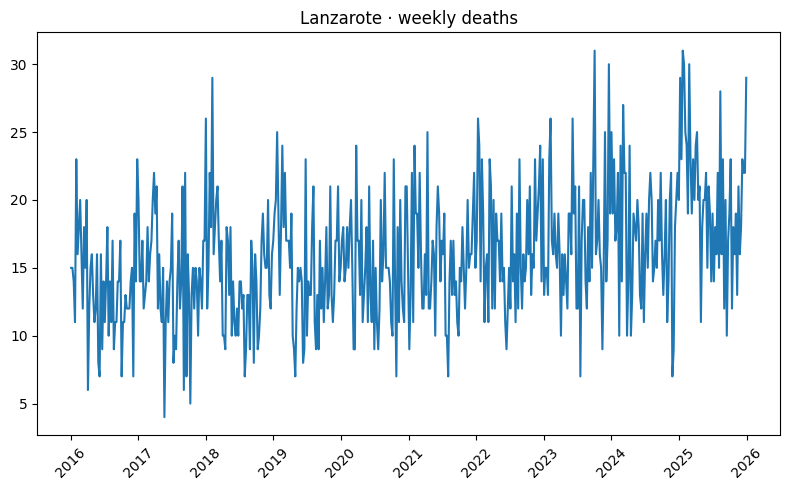

Saved figure -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\figures\lanzarote\lzt_eda01_weekly_tmax_timeseries.png


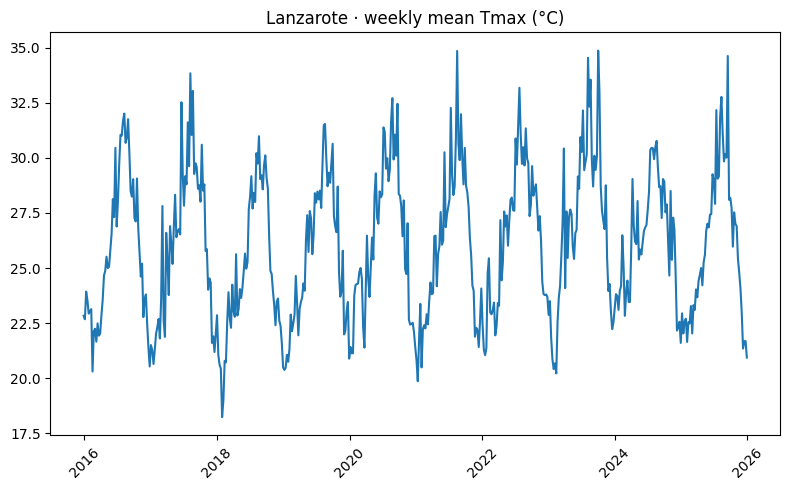

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(df["week_start"], df["deaths_week"])
plt.title(f"{ISLAND_NAME.capitalize()} · weekly deaths")
plt.xticks(rotation=45)
plt.tight_layout()
autosave_fig(FIG_DIR / f"{ISLAND_CODE}_eda01_weekly_deaths_timeseries.png")
plt.show()

if "tmax_c_mean" in df.columns:
    plt.figure(figsize=(8, 5))
    plt.plot(df["week_start"], df["tmax_c_mean"])
    plt.title(f"{ISLAND_NAME.capitalize()} · weekly mean Tmax (°C)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    autosave_fig(FIG_DIR / f"{ISLAND_CODE}_eda01_weekly_tmax_timeseries.png")
    plt.show()

## 5. Temperature and mortality
### 5.1 Absolute temperature vs deaths
Absolute temperature can be heavily confounded by seasonality.

Saved figure -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\figures\lanzarote\lzt_eda01_deaths_vs_absolute_tmax_scatter.png


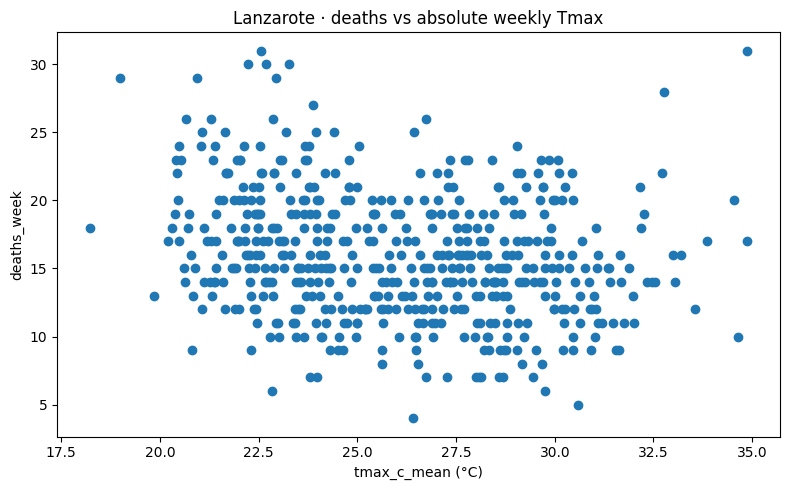

corr(deaths, tmax_c_mean): -0.2344


In [13]:
if {"tmax_c_mean", "deaths_week"}.issubset(df.columns):
    plt.figure(figsize=(8, 5))
    plt.scatter(df["tmax_c_mean"], df["deaths_week"])
    plt.xlabel("tmax_c_mean (°C)")
    plt.ylabel("deaths_week")
    plt.title(f"{ISLAND_NAME.capitalize()} · deaths vs absolute weekly Tmax")
    plt.tight_layout()
    autosave_fig(FIG_DIR / f"{ISLAND_CODE}_eda01_deaths_vs_absolute_tmax_scatter.png")
    plt.show()

    corr_abs = df[["deaths_week", "tmax_c_mean"]].corr().iloc[0, 1]
    print("corr(deaths, tmax_c_mean):", round(float(corr_abs), 4))

##### 5.2 Temperature anomaly vs deaths
Use anomalies (relative temperature) to reduce seasonal confounding.

Saved figure -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\figures\lanzarote\lzt_eda01_deaths_vs_temperature_anomaly_scatter.png


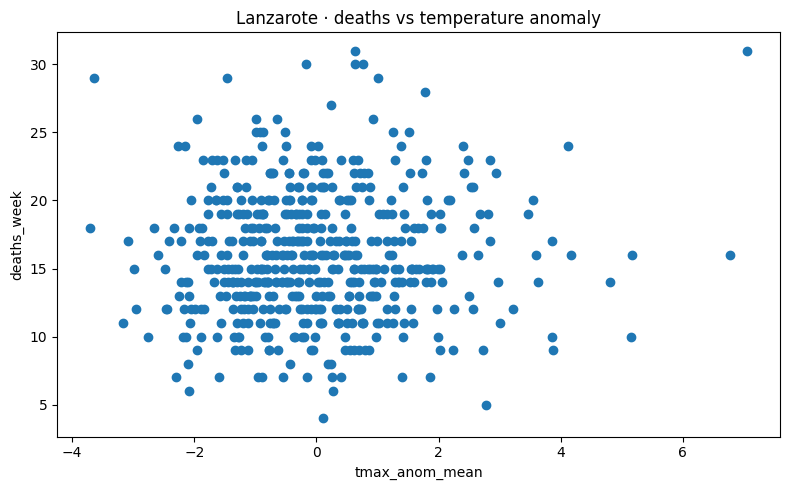

corr(deaths, tmax_anom_mean): 0.0447


In [14]:
anom_col = None
for c in ["tmax_anom_mean_week", "tmax_anom_mean", "tmax_anom_c_mean", "tmax_anom"]:
    if c in df.columns:
        anom_col = c
        break

if anom_col is None:
    print("No anomaly column found in this master. (Skip or create anomalies upstream.)")
else:
    plt.figure(figsize=(8, 5))
    plt.scatter(df[anom_col], df["deaths_week"])
    plt.xlabel(anom_col)
    plt.ylabel("deaths_week")
    plt.title(f"{ISLAND_NAME.capitalize()} · deaths vs temperature anomaly")
    plt.tight_layout()
    autosave_fig(FIG_DIR / f"{ISLAND_CODE}_eda01_deaths_vs_temperature_anomaly_scatter.png")
    plt.show()

    corr_anom = df[["deaths_week", anom_col]].corr().iloc[0, 1]
    print(f"corr(deaths, {anom_col}):", round(float(corr_anom), 4))

### 5.3 Extreme heat (p90 / p95)
Compare weeks above an extreme threshold vs the rest.

In [15]:
q90_tmax = df["tmax_c_mean"].quantile(0.90)
q95_tmax = df["tmax_c_mean"].quantile(0.95)

df["heat_p90"] = (df["tmax_c_mean"] >= q90_tmax).astype(int)
df["heat_p95"] = (df["tmax_c_mean"] >= q95_tmax).astype(int)

print(f"Empirical thresholds from weekly tmax_c_mean -> p90={q90_tmax:.2f}, p95={q95_tmax:.2f}")
print(df["heat_p95"].value_counts(dropna=False))

Empirical thresholds from weekly tmax_c_mean -> p90=30.42, p95=31.40
heat_p95
0    496
1     27
Name: count, dtype: int64


In [16]:
tmp = df.copy()
tab_p95 = tmp.groupby("heat_p95")["deaths_week"].agg(["count", "mean", "median"])
display(tab_p95)

if 0 in tab_p95.index and 1 in tab_p95.index:
    delta_p95 = float(tab_p95.loc[1, "mean"] - tab_p95.loc[0, "mean"])
    print("Δ deaths (heat_p95 vs baseline):", round(delta_p95, 2))

,count,mean,median
heat_p95,,,
0,495,15.935354,15.0
1,27,15.777778,14.0


Δ deaths (heat_p95 vs baseline): -0.16


In [17]:
save_table(tab_p95.reset_index(), TAB_DIR, f"heat_p95_deaths_{ISLAND_CODE}.csv", index=False)

Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\lanzarote\heat_p95_deaths_lzt.csv


WindowsPath('C:/Users/fdora/RA_Career/Projects/climate_mortality/reports/islands/tables/lanzarote/heat_p95_deaths_lzt.csv')

## 6. Calima and mortality
Analyze calima intensity proxies vs weekly deaths.

### 6.1 Calima proxy audit
Validate the merged calima proxy coverage and weekly level distribution before using it in downstream comparisons.

,missing,missing_pct
calima_proxy_score,0,0.0
calima_proxy_level,0,0.0


Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\lanzarote\calima_proxy_audit_missing_lzt.csv


,calima_proxy_level,weeks
0,no_calima,342
1,possible,86
2,probable,54
3,intense,41


Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\lanzarote\calima_proxy_level_counts_lzt.csv
Saved figure -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\figures\lanzarote\lzt_eda01_calima_proxy_level_distribution.png


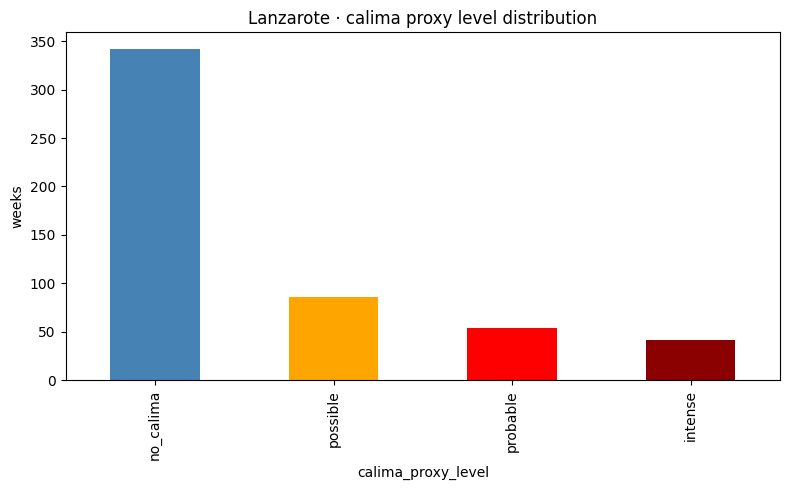

cap_dust_yellow_plus_week,0.0,1.0,NaN
calima_proxy_level,,,
intense,22,15,4
no_calima,252,3,87
possible,57,4,25
probable,33,8,13


In [18]:
proxy_cols = ["calima_proxy_score", "calima_proxy_level"]
have_proxy = all(c in df.columns for c in proxy_cols)

if have_proxy:
    proxy_na = df[proxy_cols].isna().sum().rename("missing").to_frame()
    proxy_na["missing_pct"] = (proxy_na["missing"] / len(df)).round(4)
    display(proxy_na)
    save_table(
        proxy_na.reset_index().rename(columns={"index": "column"}),
        TAB_DIR,
        f"calima_proxy_audit_missing_{ISLAND_CODE}.csv",
        index=False
    )

    proxy_counts = (
        df["calima_proxy_level"]
        .value_counts(dropna=False)
        .rename_axis("calima_proxy_level")
        .reset_index(name="weeks")
    )
    display(proxy_counts)
    save_table(proxy_counts, TAB_DIR, f"calima_proxy_level_counts_{ISLAND_CODE}.csv", index=False)

    plot_counts = df["calima_proxy_level"].dropna().value_counts()
    if not plot_counts.empty:
        desired_order = ["no_calima", "possible", "probable", "intense"]
        plot_counts = plot_counts.reindex([x for x in desired_order if x in plot_counts.index]).dropna()

        plt.figure(figsize=(8, 5))
        plot_counts.plot(kind="bar", color=["steelblue", "orange", "red", "darkred"])
        plt.ylabel("weeks")
        plt.title(f"{ISLAND_NAME.capitalize()} · calima proxy level distribution")
        plt.tight_layout()
        autosave_fig(FIG_DIR / f"{ISLAND_CODE}_eda01_calima_proxy_level_distribution.png")
        plt.show()

    if "cap_dust_yellow_plus_week" in df.columns:
        cap_xtab = pd.crosstab(df["calima_proxy_level"], df["cap_dust_yellow_plus_week"], dropna=False)
        display(cap_xtab)

In [19]:
score_dist = (
    df["calima_proxy_score"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("calima_proxy_score")
    .reset_index(name="weeks")
)

score_dist["pct"] = score_dist["weeks"] / len(df) * 100
score_dist["pct"] = score_dist["pct"].round(6)

display(score_dist)

save_table(
    score_dist,
    TAB_DIR,
    f"calima_proxy_score_distribution_{ISLAND_CODE}.csv",
    index=False
)

,calima_proxy_score,weeks,pct
0,0.0000,173,33.078394
1,0.0625,33,6.309751
2,0.1250,127,24.282983
3,0.1875,9,1.720841
4,0.2500,42,8.030593
5,0.3125,13,2.485660
6,0.3750,21,4.015296
7,0.4375,10,1.912046
8,0.5000,16,3.059273
9,0.5625,22,4.206501


Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\lanzarote\calima_proxy_score_distribution_lzt.csv


WindowsPath('C:/Users/fdora/RA_Career/Projects/climate_mortality/reports/islands/tables/lanzarote/calima_proxy_score_distribution_lzt.csv')

In [20]:
score_level = df.groupby(["calima_proxy_score", "calima_proxy_level"]).size().reset_index(name="weeks")
display(score_level)
save_table(score_level, TAB_DIR, f"calima_proxy_score_to_level_{ISLAND_CODE}.csv", index=False)

,calima_proxy_score,calima_proxy_level,weeks
0,0.0000,no_calima,173
1,0.0625,no_calima,33
2,0.1250,no_calima,127
3,0.1875,no_calima,9
4,0.2500,possible,42
5,0.3125,possible,13
6,0.3750,possible,21
7,0.4375,possible,10
8,0.5000,probable,16
9,0.5625,probable,22


Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\lanzarote\calima_proxy_score_to_level_lzt.csv


WindowsPath('C:/Users/fdora/RA_Career/Projects/climate_mortality/reports/islands/tables/lanzarote/calima_proxy_score_to_level_lzt.csv')

### 6.2 Calima levels and deaths
Compare weekly deaths across calima proxy levels (or DAI fallback if proxy columns are unavailable).

In [21]:
if "calima_proxy_level" in df.columns:
    level_order = ["no_calima", "possible", "probable", "intense"]

    cal = (
        df.groupby("calima_proxy_level")["deaths_week"]
        .agg(["count", "mean", "median", "min", "max", "std"])
        .reindex(level_order)
    )
    display(cal)
    save_table(cal.reset_index(), TAB_DIR, f"calima_proxy_level_v_deaths_{ISLAND_CODE}.csv", index=False)
else:
    print("No calima_proxy_level. Using calima_dai_flag if available...")
    if "calima_dai_flag" in df.columns:
        cal = df.groupby("calima_dai_flag")["deaths_week"].agg(["count", "mean", "median"]).sort_index()
        display(cal)
        save_table(cal.reset_index(), TAB_DIR, f"calima_dai_flag_deaths_{ISLAND_CODE}.csv", index=False)

if "intense" in cal.index and "no_calima" in cal.index:
    mean_intense = cal.loc["intense", "mean"]
    mean_baseline = cal.loc["no_calima", "mean"]
    delta_deaths = mean_intense - mean_baseline

    print(f"Mean deaths | intense   : {mean_intense:.2f}")
    print(f"Mean deaths | no_calima : {mean_baseline:.2f}")
    print(f"Δ deaths (calima intense vs baseline) = {delta_deaths:.2f}")

,count,mean,median,min,max,std
calima_proxy_level,,,,,,
no_calima,341,15.765396,15.0,4.0,31.0,4.704576
possible,86,15.790698,15.0,6.0,30.0,4.325346
probable,54,15.648148,15.0,7.0,28.0,4.518964
intense,41,17.926829,18.0,5.0,31.0,5.212438


Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\lanzarote\calima_proxy_level_v_deaths_lzt.csv
Mean deaths | intense   : 17.93
Mean deaths | no_calima : 15.77
Δ deaths (calima intense vs baseline) = 2.16


In [22]:
tmp = df.copy()
tmp["month"] = pd.to_datetime(tmp["week_start"]).dt.month

month_proxy = (
    tmp.groupby(["month", "calima_proxy_level"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

display(month_proxy)

save_table(
    month_proxy,
    TAB_DIR,
    f"calima_proxy_level_by_month_{ISLAND_CODE}.csv",
    index=False
)

calima_proxy_level,month,intense,no_calima,possible,probable
0,1,7,26,7,5
1,2,10,21,2,8
2,3,3,30,6,4
3,4,3,32,4,4
4,5,0,35,8,2
5,6,0,35,5,2
6,7,2,26,11,6
7,8,3,26,8,7
8,9,1,27,10,5
9,10,4,29,10,2


Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\lanzarote\calima_proxy_level_by_month_lzt.csv


WindowsPath('C:/Users/fdora/RA_Career/Projects/climate_mortality/reports/islands/tables/lanzarote/calima_proxy_level_by_month_lzt.csv')

Saved figure -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\figures\lanzarote\deaths_by_calima_proxy_level_boxplot_lzt.png


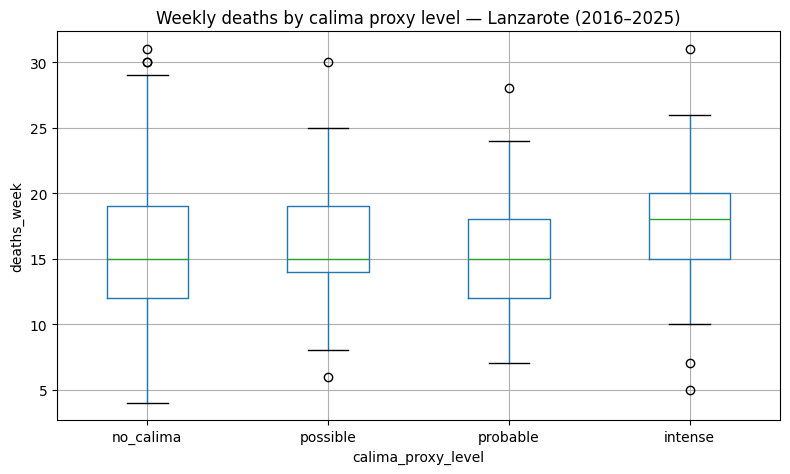

In [23]:
level_order = ["no_calima", "possible", "probable", "intense"]

plot_df = df.dropna(subset=["calima_proxy_level", "deaths_week"]).copy()
plot_df["calima_proxy_level"] = pd.Categorical(
    plot_df["calima_proxy_level"],
    categories=level_order,
    ordered=True
)
plot_df = plot_df.sort_values("calima_proxy_level")

fig, ax = plt.subplots(figsize=(8, 5))
plot_df.boxplot(column="deaths_week", by="calima_proxy_level", ax=ax)

ax.set_title(f"Weekly deaths by calima proxy level — {ISLAND_NAME.capitalize()} (2016–2025)")
ax.set_xlabel("calima_proxy_level")
ax.set_ylabel("deaths_week")
plt.suptitle("")
plt.tight_layout()

autosave_fig(FIG_DIR / f"deaths_by_calima_proxy_level_boxplot_{ISLAND_CODE}.png")
plt.show()

## 7. Interaction: extreme heat × calima
A simple 2×2 cross-tab.

In [24]:
tmp = df.copy()

if "calima_proxy_level" in tmp.columns:
    tmp["calima_intense"] = (tmp["calima_proxy_level"] == "intense").astype(int)
else:
    tmp["calima_intense"] = 0

inter = tmp.groupby(["heat_p95", "calima_intense"])["deaths_week"].agg(["count", "mean", "median"])
display(inter)

save_table(
    inter.reset_index(),
    TAB_DIR,
    f"interaction_heat_p95_x_calima_intense_{ISLAND_CODE}.csv",
    index=False
)

count       mean  median
heat_p95 calima_intense                          
0        0                 459  15.795207    15.0
         1                  36  17.722222    18.0
1        0                  22  14.954545    14.0
         1                   5  19.400000    19.0

Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\lanzarote\interaction_heat_p95_x_calima_intense_lzt.csv


WindowsPath('C:/Users/fdora/RA_Career/Projects/climate_mortality/reports/islands/tables/lanzarote/interaction_heat_p95_x_calima_intense_lzt.csv')

In [25]:
summary = {}

# 1) Δ deaths: heat p95 vs baseline
if "heat_p95" in df.columns and "deaths_week" in df.columns:
    heat_base = df.loc[df["heat_p95"] == 0, "deaths_week"].mean()
    heat_p95 = df.loc[df["heat_p95"] == 1, "deaths_week"].mean()
    summary["deaths_mean_baseline_heat"] = heat_base
    summary["deaths_mean_heat_p95"] = heat_p95
    summary["delta_deaths_heat_p95_vs_baseline"] = heat_p95 - heat_base
else:
    summary["deaths_mean_baseline_heat"] = np.nan
    summary["deaths_mean_heat_p95"] = np.nan
    summary["delta_deaths_heat_p95_vs_baseline"] = np.nan

# 2) Δ deaths: calima intense vs baseline
if "calima_proxy_level" in df.columns and "deaths_week" in df.columns:
    cal_base = df.loc[df["calima_proxy_level"] == "no_calima", "deaths_week"].mean()
    cal_intense = df.loc[df["calima_proxy_level"] == "intense", "deaths_week"].mean()
    summary["deaths_mean_no_calima"] = cal_base
    summary["deaths_mean_intense_calima"] = cal_intense
    summary["delta_deaths_intense_vs_no_calima"] = cal_intense - cal_base
else:
    summary["deaths_mean_no_calima"] = np.nan
    summary["deaths_mean_intense_calima"] = np.nan
    summary["delta_deaths_intense_vs_no_calima"] = np.nan

# 3) Proxy missingness
if "calima_proxy_score" in df.columns:
    summary["proxy_missing_n"] = int(df["calima_proxy_score"].isna().sum())
    summary["proxy_missing_pct"] = df["calima_proxy_score"].isna().mean() * 100
else:
    summary["proxy_missing_n"] = np.nan
    summary["proxy_missing_pct"] = np.nan

# 4) Correlation: deaths vs absolute temperature
temp_col = None
for c in ["tmax_mean", "tmax_c_mean", "tmean_mean", "tmean_c_mean"]:
    if c in df.columns:
        temp_col = c
        break

if temp_col is not None and "deaths_week" in df.columns:
    summary["temp_corr_col_used"] = temp_col
    summary["corr_deaths_vs_temp"] = df["deaths_week"].corr(df[temp_col])
else:
    summary["temp_corr_col_used"] = None
    summary["corr_deaths_vs_temp"] = np.nan

# 5) Correlation: deaths vs temperature anomaly
anom_col = None
for c in ["tmax_anom_mean", "tmean_anom_mean", "temp_anom_mean"]:
    if c in df.columns:
        anom_col = c
        break

if anom_col is not None and "deaths_week" in df.columns:
    summary["anom_corr_col_used"] = anom_col
    summary["corr_deaths_vs_anomaly"] = df["deaths_week"].corr(df[anom_col])
else:
    summary["anom_corr_col_used"] = None
    summary["corr_deaths_vs_anomaly"] = np.nan

# Output table
summary_df = pd.DataFrame(
    {"metric": summary.keys(), "value": summary.values()}
)

display(Markdown(f"""
### Key numbers — {ISLAND_NAME.upper()}
<hr></hr>

**Δ deaths (heat p95 vs baseline):** {summary['delta_deaths_heat_p95_vs_baseline']:.2f}

**Δ deaths (intense calima vs no_calima):** {summary['delta_deaths_intense_vs_no_calima']:.2f} deaths/week

**Proxy missingness:** {summary['proxy_missing_n']} weeks ({summary['proxy_missing_pct']:.2f}%)

**Corr deaths vs temp ({summary['temp_corr_col_used']}):** {summary['corr_deaths_vs_temp']:.3f}

**Corr deaths vs anomaly ({summary['anom_corr_col_used']}):** {summary['corr_deaths_vs_anomaly']:.3f}
<br></br>
"""))
save_table(
    summary_df,
    TAB_DIR,
    f"key_numbers_auto_{ISLAND_CODE}.csv",
    index=False
)


### Key numbers — LANZAROTE
<hr></hr>

**Δ deaths (heat p95 vs baseline):** -0.16

**Δ deaths (intense calima vs no_calima):** 2.16 deaths/week

**Proxy missingness:** 0 weeks (0.00%)

**Corr deaths vs temp (tmax_c_mean):** -0.234

**Corr deaths vs anomaly (tmax_anom_mean):** 0.045
<br></br>


Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\lanzarote\key_numbers_auto_lzt.csv


WindowsPath('C:/Users/fdora/RA_Career/Projects/climate_mortality/reports/islands/tables/lanzarote/key_numbers_auto_lzt.csv')